**Цель:** Изучение архитектуры CNN, методов оптимизации и трансферного обучения.



## Теоретические сведения о сверточных нейронных сетях
Сверточные нейронные сети (CNN) используют сверточные слои, в которых набор обучаемых фильтров (ядер) скользит по входному изображению. Во время прямого прохода каждое ядро свертывается по ширине и высоте входного тензора, вычисляя скалярное произведение между элементами фильтра и входа и создавая двумерную карту активаций. Стекинг карт активаций разных фильтров по глубинной оси формирует выходной объём слоя, а использование одного и того же набора параметров для всех позиций уменьшает число свободных параметров (это называется разделением параметров).

Размер выходного тензора сверточного слоя определяется тремя гиперпараметрами: глубиной (число фильтров), шагом (stride) и паддингом (padding). Шаг задаёт, на сколько пикселей смещается ядро при сканировании входа; если шаг равен 1, фильтр перемещается по одному пикселю и выходной тензор имеет большие размеры. Паддинг дополняет вход нулями по краям, позволяя управлять размером выхода и, например, сохранять пространственные размеры входа.

После сверточного слоя часто используется слой пулинга для уменьшения размерности и повышения устойчивости к сдвигам. Пулинг комбинирует значения на локальном участке карты признаков; наиболее популярны максимальный пулинг, выбирающий максимальное значение, и усредняющий пулинг, вычисляющий среднее на участке.

Транспонированная свёртка (иногда называемая «deconvolution») служит для повышения разрешения карты признаков. В отличие от обычной свёртки, где ядро скользит по входу, транспонированная свёртка «разворачивает» вход: входной тензор скользит по ядру, что приводит к выходу большего размера. Эта операция используется для генерации изображений, супер‑разрешения и сегментации. Размер выхода зависит от шага и паддинга: для ядра размера \(K_h	imes K_w\), входа \(I_h	imes I_w\), шага \(s_h, s_w\) и паддинга \(p\) высота и ширина выхода вычисляются как \(O_h = (I_h - 1)s_h + K_h - 2p\) и \(O_w = (I_w - 1)s_w + K_w - 2p\).

## Задание 1. Реализация функций свёртки и пулинга
Необходимо написать функцию `conv2d`, которая применяет свёртку к изображению с заданным ядром (`kernel`), шагом (`stride`) и паддингом (`padding`). В этой же задаче реализуйте функции `max_pool2d` и `avg_pool2d` с заданным размером окна (`pool_size`) и шагом (`stride`). Используйте паддинг `'valid'` или `'same'` либо укажите целое количество элементов для добавления по краям.

In [134]:
import numpy as np

def conv2d(image, kernel, stride=1, padding='valid'):
    h_k, w_k = kernel.shape

    if isinstance(padding, int):
        p_h = padding
        p_w = padding
    elif padding == 'same':
        p_h = (h_k - 1) // 2
        p_w = (w_k - 1) // 2
    elif padding == 'valid':
        p_h = 0
        p_w = 0
    else:
        raise ValueError("padding must be 'valid', 'same' or an int")

    if p_h > 0 or p_w > 0:
        image = np.pad(image, ((p_h, p_h), (p_w, p_w)), mode='constant')

    h_p, w_p = image.shape

    h_o = (h_p - h_k) // stride + 1
    w_o = (w_p - w_k) // stride + 1

    out = np.zeros((h_o, w_o))

    for i in range(h_o):
        for j in range(w_o):
            r_s = i * stride
            r_e = r_s + h_k
            c_s = j * stride
            c_e = c_s + w_k
            w = image[r_s:r_e, c_s:c_e]
            out[i, j] = np.sum(w * kernel)

    return out

# Пример использования
image = np.random.rand(5, 5)
kernel = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
result = conv2d(image, kernel, stride=2, padding="valid")
display(result)
print(result.shape)  # Ожидается (3, 3)

array([[-1.75485829,  0.39297565],
       [-1.63703133,  1.05919747]])

(2, 2)


In [137]:
def max_pool2d(image, pool_size=2, stride=2, padding = "valid"):
    p_h, p_w = pool_size, pool_size

    if padding == 'same':
        pad_h = (p_h - 1) // 2
        pad_w = (p_w - 1) // 2
    elif padding == 'valid':
        pad_h, pad_w = 0, 0
    else:
        raise ValueError("padding must be 'valid' or 'same'")

    if pad_h > 0 or pad_w > 0:
        image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    h_p, w_p = image.shape
    
    h_o = (h_p - p_h) // stride + 1
    w_o = (w_p - p_w) // stride + 1
    
    out = np.zeros((h_o, w_o))

    for i in range(h_o):
        for j in range(w_o):
            r_s = i * stride
            r_e = r_s + p_h
            c_s = j * stride
            c_e = c_s + p_w
            w = image[r_s:r_e, c_s:c_e]
            out[i, j] = np.max(w)
            
    return out

def avg_pool2d(image, pool_size=2, stride=1, padding='valid'):
    h_i, w_i = image.shape
    p_h, p_w = pool_size, pool_size

    if padding == 'same':
        pad_h = (p_h - 1) // 2
        pad_w = (p_w - 1) // 2
    elif padding == 'valid':
        pad_h, pad_w = 0, 0
    else:
        raise ValueError("padding must be 'valid' or 'same'")
        
    if pad_h > 0 or pad_w > 0:
        image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    h_p, w_p = image.shape
    
    h_o = (h_p - p_h) // stride + 1
    w_o = (w_p - p_w) // stride + 1
    
    out = np.zeros((h_o, w_o))

    for i in range(h_o):
        for j in range(w_o):
            r_s = i * stride
            r_e = r_s + p_h
            c_s = j * stride
            c_e = c_s + p_w
            w = image[r_s:r_e, c_s:c_e]
            out[i, j] = np.mean(w)
            
    return out

image = np.random.rand(5, 5)
kernel = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
convolve = conv2d(image, kernel, stride=1, padding='valid')
print(convolve)
pooled = avg_pool2d(convolve, pool_size=2, stride=1)
pooled

[[-0.37074523  1.13599891  0.24531926]
 [-0.66895822  1.2075292  -0.1527287 ]
 [-1.13893765  0.8057871   0.19807517]]


array([[0.32595617, 0.60902967],
       [0.05135511, 0.51466569]])

In [138]:
pooled = max_pool2d(convolve, pool_size=2, stride=1)
pooled

array([[1.2075292, 1.2075292],
       [1.2075292, 1.2075292]])

In [125]:
pooled = max_pool2d(image, stride=1)
pooled

array([[0.91574387, 0.97284485, 0.97284485, 0.83395919],
       [0.94199982, 0.91574387, 0.84486303, 0.84304107],
       [0.94199982, 0.84486303, 0.84486303, 0.84304107],
       [0.75356039, 0.66601736, 0.70801104, 0.70801104]])

## Задание 2. Транспонированная свёртка 1D
Напишите функцию `transposed_conv1d` (или аналогично названную), которая реализует транспонированную (обратную) свёртку для одномерного сигнала. Функция должна принимать входной массив, ядро, шаг (`stride`, по умолчанию 1) и паддинг (`padding`, по умолчанию 0). Вывод функции должен иметь длину \((n-1) 	× stride + k - 2 	× padding\), где \(n\) — длина входа, а \(k\) — длина ядра.

In [139]:
def transposed_conv1d(x, kernel, stride=1, padding=0):
    """
    Реализует транспонированную 1D свёртку (также известную как 'полную' свёртку) для одномерного массива.
    Параметры:
    x : np.ndarray — входной 1D сигнал.
    kernel : np.ndarray — ядро свёртки.
    stride : int — шаг между элементами входа.
    padding : int — количество элементов, удаляемых с края после свёртки.
    """
    n = len(x)
    x_up = np.zeros((n - 1) * stride + 1)
    x_up[::stride] = x
    
    res = np.convolve(x_up, kernel, mode='full')
    
    if padding > 0:
        res = res[padding:-padding]
        
    return res

# Пример использования
x = np.array([1, 2, 3, 4])
k = np.array([1, 0, -1])
print(transposed_conv1d(x, k))

[ 1.  2.  2.  2. -3. -4.]


## Задание 3. Транспонированная свёртка 2D
Реализуйте функцию `transposed_conv2d`, которая выполняет транспонированную свёртку для двумерного изображения. Функция принимает входной массив, ядро, шаг (`stride`, целое или кортеж), паддинг (`padding`) и возвращает выход размером \(((H-1) 	imes stride_h + K_h - 2	imes padding), ((W-1) 	imes stride_w + K_w - 2	imes padding)\).

In [113]:
def transposed_conv2d(x, kernel, stride=1, padding=0):
    """
    Реализует транспонированную 2D свёртку для изображений.
    Параметры:
    x : np.ndarray — входной 2D массив.
    kernel : np.ndarray — ядро свёртки (2D).
    stride : int или tuple — шаг по вертикали и горизонтали.
    padding : int или tuple — паддинг, количество удаляемых строк/столбцов с краёв.
    """
    if isinstance(stride, int):
        s_h = stride
        s_w = stride
    else:
        s_h, s_w = stride

    if isinstance(padding, int):
        p_h = padding
        p_w = padding
    else:
        p_h, p_w = padding

    h_x, w_x = x.shape
    h_up = (h_x - 1) * s_h + 1
    w_up = (w_x - 1) * s_w + 1
    x_up = np.zeros((h_up, w_up))
    x_up[::s_h, ::s_w] = x
    
    res = conv2d(x_up, kernel)
    
    h_start = p_h
    h_end = res.shape[0] - p_h
    w_start = p_w
    w_end = res.shape[1] - p_w
    
    return res[h_start:h_end, w_start:w_end]

# Пример использования
image = np.array([[1, 2], [3, 4]])
kernel = np.array([[0, 1], [2, 3]])
print(transposed_conv2d(image, kernel))

[[20.]]


## Задание 4. Класс трёхслойной сверточной сети с пулингом и нормализацией
Создайте класс `ThreeLayerConvNet`, реализующий простую сверточную сеть из трёх сверточных слоёв. Каждый свёрточный слой должен использовать функцию `conv2d` (реализованную в задании 1), за ним применяется функция активации (например, ReLU), слой пулинга (`max_pool2d` или `avg_pool2d`) и нормализация (например, Batch Normalization на numpy). Класс должен предоставлять метод `forward(x)`, принимающий входной двумерный массив и возвращающий выход сети.

In [ ]:
class ThreeLayerConvNet:
    def __init__(self, kernels, strides=1, paddings='valid', pool_size=2, pool_stride=2):
        pass
        Инициализирует трёхслойную сверточную сеть.
        kernels : список из трёх 2D ядер.
        strides : int или список длины 3 — шаги свёртки для каждого слоя.
        paddings : аналогично strides — паддинг для каждого слоя.
        pool_size : размер окна для пулинга.
        pool_stride : шаг для пулинга.
        """
        self.kernels = kernels
        if isinstance(strides, int):
            self.strides = [strides] * 3
        else:
            self.strides = strides
        if isinstance(paddings, (int, str)):
            self.paddings = [paddings] * 3
        else:
            self.paddings = paddings
        self.pool_size = pool_size
        self.pool_stride = pool_stride
    def batch_norm(self, x, eps=1e-5):
        """
        Простая реализация batch normalization для 2D массива.
        """
        mean = np.mean(x)
        var = np.var(x)
        return (x - mean) / np.sqrt(var + eps)
    def forward(self, x):
        """
        Выполняет прямой проход через сеть.
        x : np.ndarray — входной 2D массив.
        """
        out = x
        for i in range(3):
            out = conv2d(out, self.kernels[i], stride=self.strides[i], padding=self.paddings[i])
            out = np.maximum(0, out)
            out = max_pool2d(out, pool_size=self.pool_size, stride=self.pool_stride)
            out = self.batch_norm(out)
        return out

# Пример использования
kernels = [np.array([[1, -1], [0, 1]]), np.array([[1, 0], [0, -1]]), np.array([[0, 1], [1, 0]])]
model = ThreeLayerConvNet(kernels, strides=1, paddings='valid')
image = np.random.rand(8, 8)
output = model.forward(image)
print(output.shape)

#Лабораторная часть

##Задание 5. Архитектура LeNet для CIFAR-10
Реализовать LeNet-5 и обучить на CIFAR-10.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras import layers, models, datasets

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

model = models.Sequential([
    ...
])

model.compile(...)

# Обучение модели
history = model.fit(...)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3159 - loss: 1.9061 - val_accuracy: 0.3966 - val_loss: 1.7041
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4240 - loss: 1.6459 - val_accuracy: 0.4524 - val_loss: 1.5462
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4714 - loss: 1.4885 - val_accuracy: 0.4836 - val_loss: 1.4646
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5086 - loss: 1.3890 - val_accuracy: 0.5020 - val_loss: 1.4048
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5377 - loss: 1.3086 - val_accuracy: 0.5064 - val_loss: 1.3908
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5582 - loss: 1.2462 - val_accuracy: 0.5197 - val_loss: 1.3585
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5745 - loss: 1.1972 - val_accuracy: 0.5331 - val_loss: 1.3401
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5941 - loss: 1.1492 

In [ ]:
# 1. Оценка качества на тестовом наборе
test_loss, test_acc = model.evaluate(...)
print(f"\nTest accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.5230 - loss: 1.5000

Test accuracy: 0.5230, Test loss: 1.5000


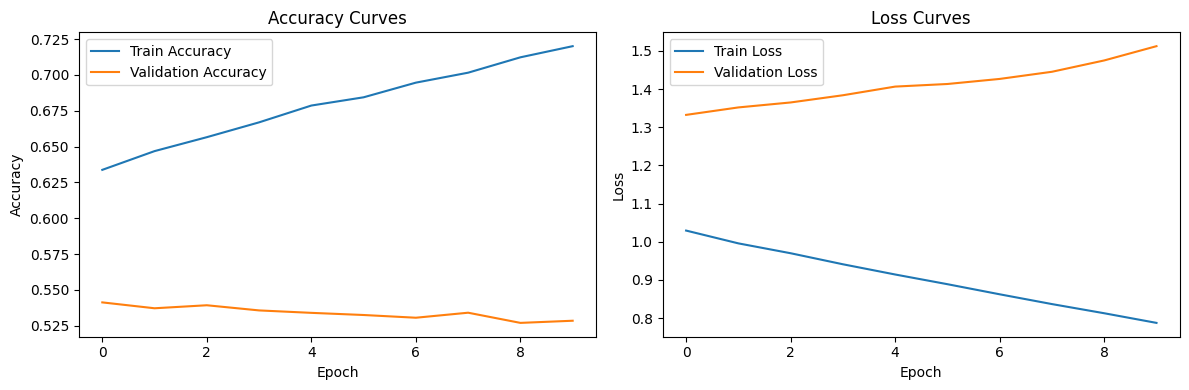

In [ ]:
# 2. Визуализация кривых обучения
...

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


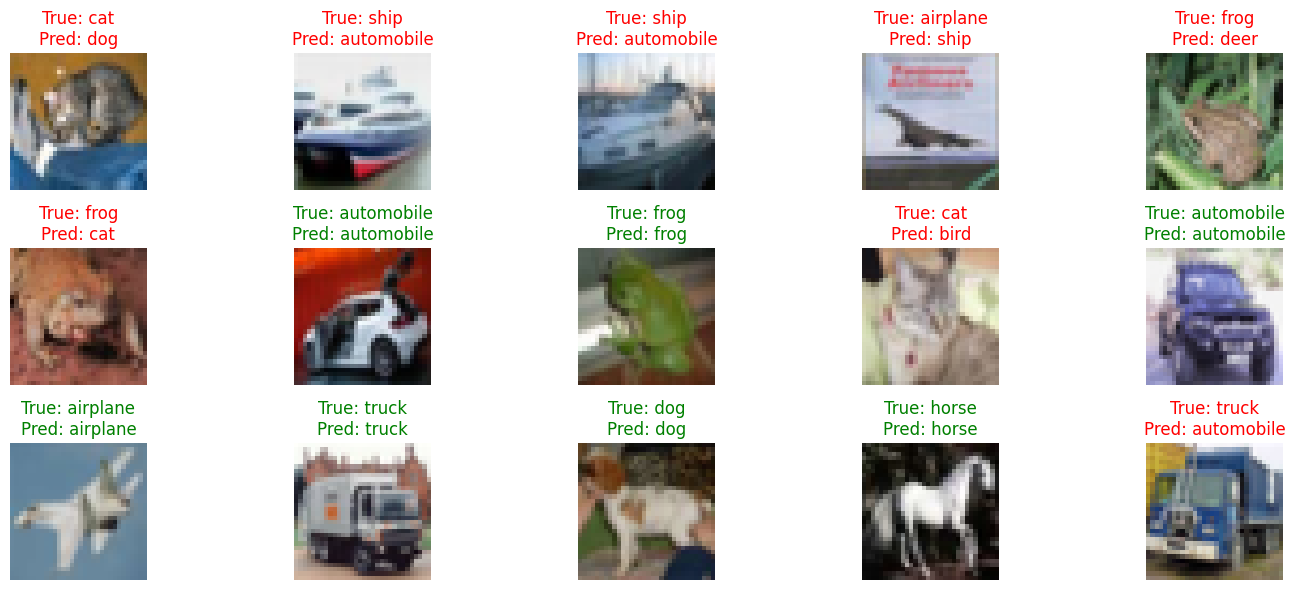

In [ ]:
# 3. Визуализация примеров с предсказаниями
predictions = model.predict(test_images)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15, 6))
for i in range(15):
    ...
plt.tight_layout()
plt.show()

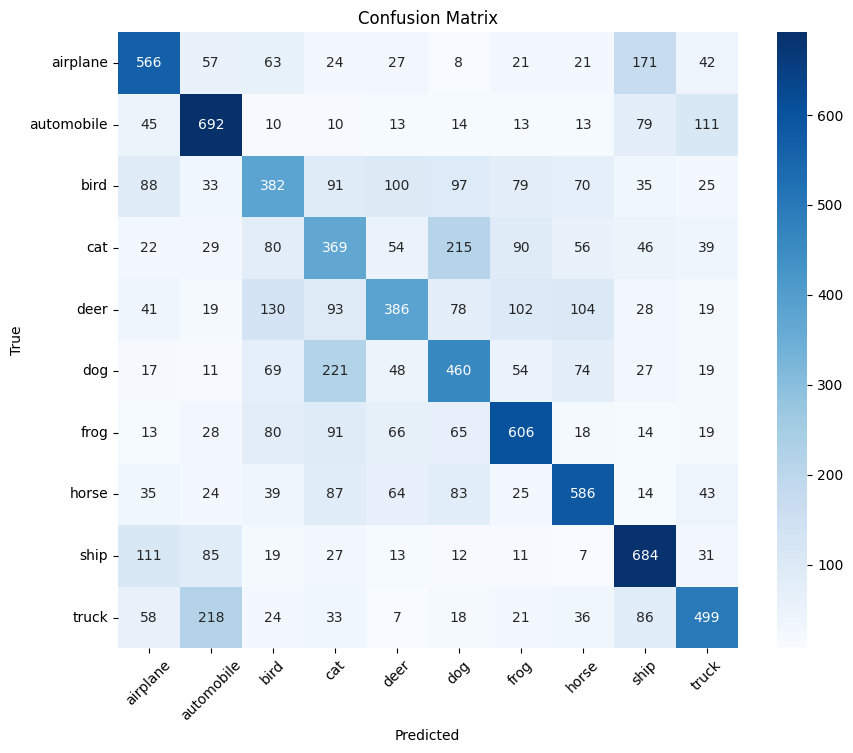

In [ ]:
# 4. Confusion Matrix
pred_labels = np.argmax(predictions, axis=1)
true_labels = test_labels.flatten()

...

In [ ]:
# 5. Classification Report
print("\nClassification Report:")
print(classification_report(...))


Classification Report:
              precision    recall  f1-score   support

    airplane       0.57      0.57      0.57      1000
  automobile       0.58      0.69      0.63      1000
        bird       0.43      0.38      0.40      1000
         cat       0.35      0.37      0.36      1000
        deer       0.50      0.39      0.43      1000
         dog       0.44      0.46      0.45      1000
        frog       0.59      0.61      0.60      1000
       horse       0.59      0.59      0.59      1000
        ship       0.58      0.68      0.63      1000
       truck       0.59      0.50      0.54      1000

    accuracy                           0.52     10000
   macro avg       0.52      0.52      0.52     10000
weighted avg       0.52      0.52      0.52     10000



##Задание 6. Добавление Dropout и BatchNorm
 Модифицировать LeNet, добавив Dropout и BatchNorm. Сравнить точность.

In [ ]:
model2 = models.Sequential([
    ...
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model2.compile(...)
# Обучение модели
history = model2.fit(...)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.3005 - loss: 2.1742 - val_accuracy: 0.4288 - val_loss: 1.6403
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.4606 - loss: 1.5007 - val_accuracy: 0.5053 - val_loss: 1.3561
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5046 - loss: 1.3890 - val_accuracy: 0.4257 - val_loss: 1.8213
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5355 - loss: 1.3148 - val_accuracy: 0.5790 - val_loss: 1.1811
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5513 - loss: 1.2693 - val_accuracy: 0.4742 - val_loss: 1.5371
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5627 - loss: 1.2336 - val_accuracy: 0.6070 - val_loss: 1.1125
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5784 - loss: 1.1922 - val_accuracy: 0.6268 - val_loss: 1.0640
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5805 - loss: 1.1832

In [ ]:
# 1. Оценка качества на тестовом наборе
test_loss, test_acc = model2.evaluate(...)
print(f"\nTest accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

313/313 - 1s - 3ms/step - accuracy: 0.6062 - loss: 1.1334

Test accuracy: 0.6062, Test loss: 1.1334


##Задание 7. Трансферное обучение с VGG16 на CIFAR-10
Использовать предобученную VGG16, заменить классификатор и дообучить.

In [ ]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import numpy as np
from tqdm import tqdm

# Настройки для ускорения
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Улучшенная предобработка данных
transform = transforms.Compose([
    transforms.Resize(64),  # Уменьшили размер для ускорения
    transforms.RandomHorizontalFlip(),  # Аугментация
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Оптимизированная загрузка данных
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

...

# Classification Report
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

<ipython-input-22-7ad9cafc4bc9>:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1:   0%|          | 0/782 [00:00<?, ?batch/s]<ipython-input-22-7ad9cafc4bc9>:83: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Testing:   0%|          | 0/40 [00:00<?, ?it/s]<ipython-input-22-7ad9cafc4bc9>:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Testing: 100%|██████████| 40/40 [00:06<00:00,  6.56it/s]


Classification Report:
              precision    recall  f1-score   support

    airplane       0.86      0.96      0.91      1000
  automobile       0.96      0.95      0.95      1000
        bird       0.92      0.88      0.90      1000
         cat       0.88      0.80      0.84      1000
        deer       0.84      0.96      0.90      1000
         dog       0.88      0.88      0.88      1000
        frog       0.96      0.92      0.94      1000
       horse       0.96      0.93      0.94      1000
        ship       0.98      0.89      0.93      1000
       truck       0.93      0.96      0.95      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



##Задание 8. Сравнение функций активации
 Обучить CNN из задания 5 с ReLU, Sigmoid, Tanh. Сравнить графики обучения.

In [ ]:
model2 = models.Sequential([
    ...
])
model2.compile(...)
# Обучение модели
history = model2.fit(...)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.2568 - loss: 2.3022 - val_accuracy: 0.3458 - val_loss: 1.9573
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.3910 - loss: 1.7220 - val_accuracy: 0.4477 - val_loss: 1.5374
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4222 - loss: 1.5998 - val_accuracy: 0.4729 - val_loss: 1.4686
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4570 - loss: 1.5007 - val_accuracy: 0.5020 - val_loss: 1.3980
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4697 - loss: 1.4636 - val_accuracy: 0.5289 - val_loss: 1.3286
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4858 - loss: 1.4320 - val_accuracy: 0.5333 - val_loss: 1.3131
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4959 - loss: 1.4008 - val_accuracy: 0.5272 - val_loss: 1.3248
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5002 - loss: 1.39

In [ ]:
# 1. Оценка качества на тестовом наборе
test_loss, test_acc = model2.evaluate(...)
print(f"\nTest accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

313/313 - 1s - 4ms/step - accuracy: 0.5497 - loss: 1.2500

Test accuracy: 0.5497, Test loss: 1.2500


##Задание 9. Визуализация предсказаний
Вывести 10 изображений из тестовой выборки с подписями истинного и предсказанного классов.

relu
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


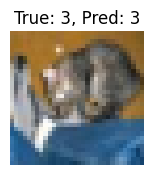

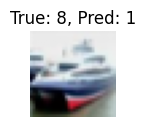

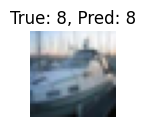

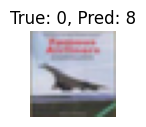

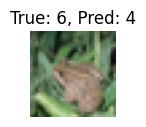

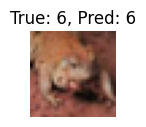

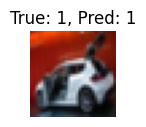

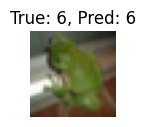

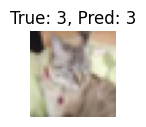

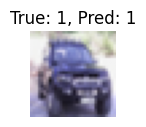

sigmoid
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


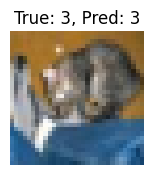

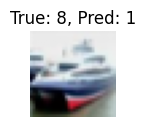

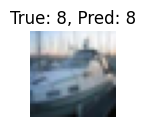

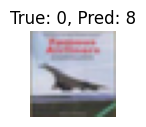

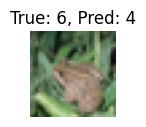

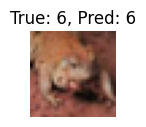

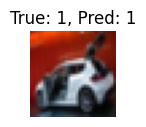

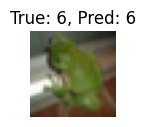

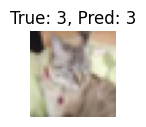

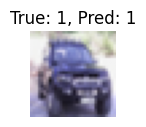

In [ ]:
import matplotlib.pyplot as plt
models = [model, model2]
activations = ['relu', 'sigmoid']
for i in range(len(models)):
  ...

##Задание 10. Оценка качества через Confusion Matrix
Построить матрицу ошибок для VGG.

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


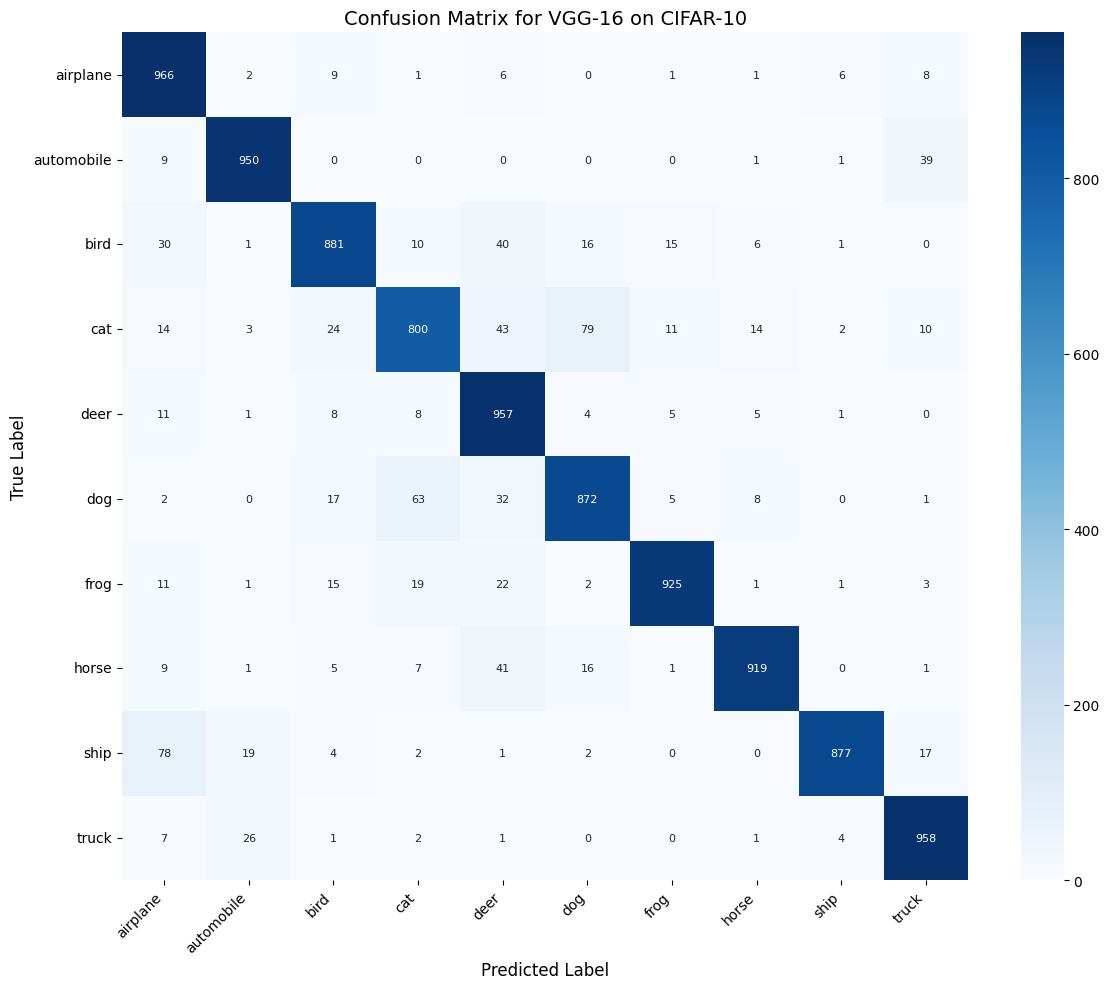

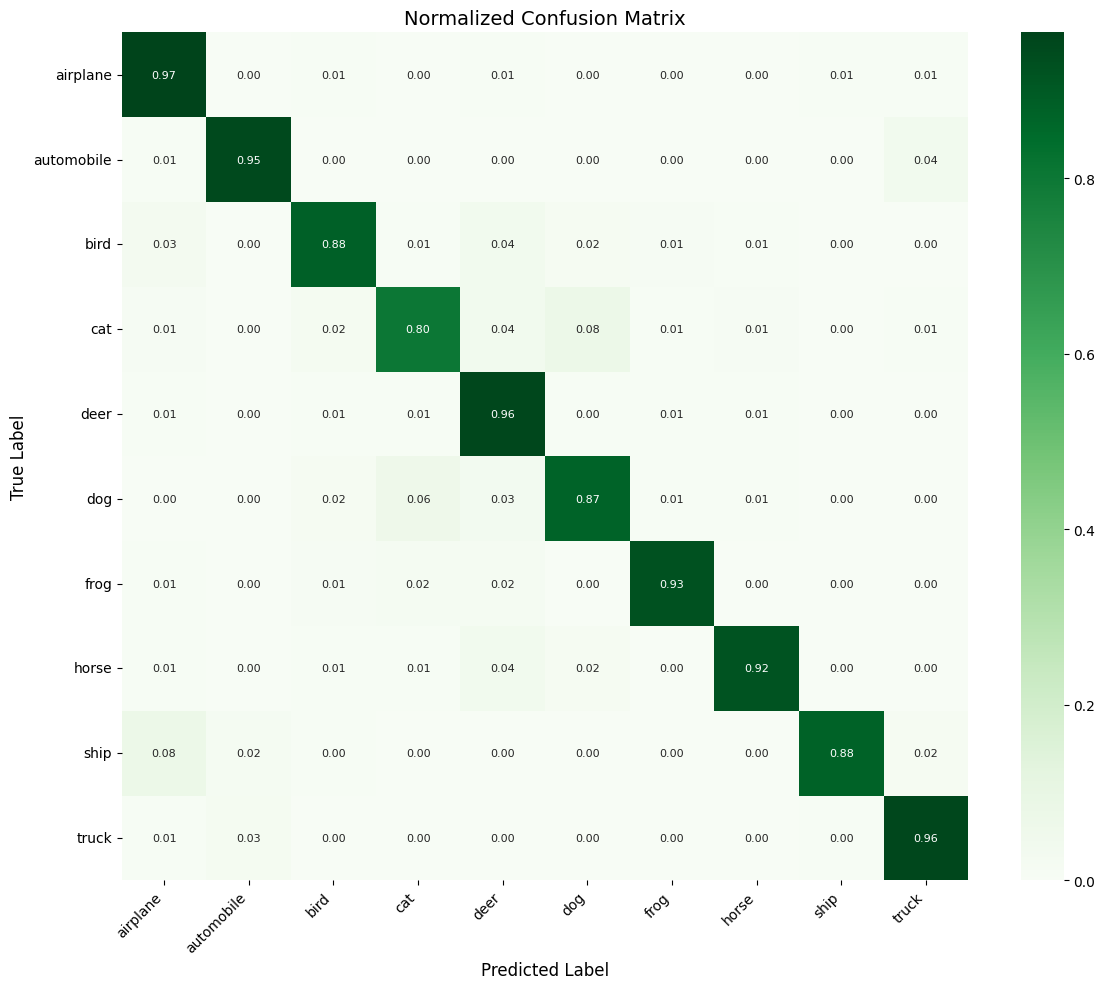

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Получение прогнозов для всего тестового набора
model3.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model3(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Преобразование в numpy arrays
pred_labels = np.array(all_preds)
true_labels = np.array(all_labels)

# Создание confusion matrix
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

...

# Нормализованная версия матрицы ошибок
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

...

##Задание 11. Поиск гиперпараметров
Использовать GridSearch для оптимизации learning rate, числа фильтров. Используйте Keras Tuner

In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 9.0 MB/s eta 0:00:00


In [ ]:
#Ваш код

Trial 48 Complete [00h 00m 34s]
val_accuracy: 0.602400004863739

Best val_accuracy So Far: 0.6980999708175659
Total elapsed time: 00h 25m 57s

Best hyperparameters:
- Conv 1 filters: 32
- Conv 2 filters: 128
- Dense units: 512
- Learning rate: 0.001



/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
